<a href="https://colab.research.google.com/github/ssykes-eth/ETH_275-0005-00L/blob/code_exercises/02_peft_finetuning_student.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WE7 · Notebook 02: One backbone, many tasks

## Adapting one pretrained model to many tasks without storing it many times

> **The situation.** You own one pretrained model, but many users want their own task-specific version of it.
>
> One group works with spectra, another with scanned forms, another needs a client-specific classifier. Soon, you may have dozens or even hundreds of target tasks.
>
> The straightforward solution is **full fine-tuning**: start from the pretrained model, fine-tune a separate copy for each task, and save the resulting model.
>
> The problem is that every task then needs its own **full checkpoint**, even though most of those models remain very similar to the same pretrained backbone. During training, each copy also requires gradients and optimiser state for all trainable parameters.
>
> **Parameter-efficient fine-tuning (PEFT)** takes a different approach: keep one shared pretrained backbone, train only a small task-specific set of parameters, and save only that small adaptation for each task.

### What you will be able to do by the end

- distinguish **total parameters** from **trainable parameters**, and understand how they affect training memory;
- implement **BitFit**, **LoRA**, and **Diff Pruning** on the same pretrained model;
- compute the number of trainable parameters in a LoRA update before running the model;
- compare full fine-tuning and PEFT methods in terms of **accuracy, training-state memory, checkpoint size, and runtime**;
- explain which trade-off makes each method useful.

Everything runs on **CPU only** and requires well under a minute of compute.

## 0. Setup

In [1]:
#@title Download { display-mode: "form" }
import os, sys, subprocess

REPO_OWNER  = "eth-fdd-fs26"
REPO_NAME   = "FDD-WE7-public"
REPO_BRANCH = "main"
HELPER      = os.path.join("2_peft_finetuning", "exercise", "peft_viz.py")

def _in_colab():
    try:
        import google.colab  # noqa: F401
        return True
    except Exception:
        return False

def _git(args):
    '''Run git without a terminal prompt: the repo is public, so no credentials are needed.'''
    env = dict(os.environ, GIT_TERMINAL_PROMPT="0")
    done = subprocess.run(args, capture_output=True, text=True, env=env)
    return done.returncode, (done.stdout + done.stderr).strip()

if _in_colab():
    url = "https://github.com/%s/%s.git" % (REPO_OWNER, REPO_NAME)

    if os.path.isdir(REPO_NAME):
        print("Updating the exercise repo to the latest version...")
        code, log = _git(["git", "-C", REPO_NAME, "pull", "-q", url, REPO_BRANCH])
    else:
        print("Cloning the exercise repo...")
        code, log = _git(["git", "clone", "-q", "-b", REPO_BRANCH, url, REPO_NAME])

    if code != 0:
        print(log)
        raise RuntimeError(
            "git failed. Check that you are online and run this cell again. If it keeps "
            "failing, delete the %r folder in the file browser (left sidebar) and retry."
            % REPO_NAME)

# Move to the REPO ROOT - the folder holding `2_peft_finetuning/exercise/` - so imports resolve.
for _root in [REPO_NAME, ".", os.path.dirname(os.getcwd()),
              os.path.dirname(os.path.dirname(os.getcwd())), os.getcwd()]:
    if os.path.exists(os.path.join(_root, HELPER)):
        os.chdir(_root)
        break
else:
    raise FileNotFoundError(
        "Cloned, but %s is not there - the clone did not bring the exercise files." % HELPER)
sys.path.insert(0, os.path.join(os.getcwd(), "2_peft_finetuning", "exercise"))
print("Working directory:", os.getcwd())

Cloning the exercise repo...
Working directory: /content/FDD-WE7-public


In [2]:
#@title Install Dependencies { display-mode: "form" }
%pip install -q -r 2_peft_finetuning/exercise/requirements_peft.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 638.7/638.7 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.2/86.2 kB 3.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires ipython==7.34.0, but you have ipython 9.17.0 which is incompatible.


In [3]:
#@title Import libraries { display-mode: "form" }
import copy, time, os
import numpy as np
import torch
import torch.nn as nn
from sklearn.datasets import make_moons

import importlib
import peft_viz as pv
importlib.reload(pv)      # pick up the latest helpers even if a stale copy was cached

torch.set_num_threads(1)  # so the measured times below mean something on any machine

SEED = 0

def seed_everything(seed=SEED):
    '''Every experiment in this notebook starts from the same random state.'''
    torch.manual_seed(seed)
    np.random.seed(seed)

seed_everything()
print("torch", torch.__version__, "· device: cpu · seeds fixed ✅")

torch 2.11.0+cpu · device: cpu · seeds fixed ✅


---
# Part 0. The cost of one model per task  ·  ~5 min

You have **one pretrained model** and many target tasks.

The simplest approach is to fine-tune and save a complete copy of the model for each task. With 100 tasks, that means **100 full checkpoints**.

Before looking at PEFT, we first ask a simple question:

> **How much storage does that require?**

The diagram below shows the setup we will compare against throughout the notebook.

In [4]:
#@title One model per task { display-mode: "form" }

pv.one_model_per_task(base_parameter_count=1_000_000_000, bytes_per_param=2, n_tasks=3)

Two numbers decide everything on that picture. Change them and see what happens.

In [5]:
base_parameter_count = 1_000_000_000      # a 1B-parameter pretrained model
number_of_tasks      = 20                 # how many adapted versions you have to keep

pv.storage_scenario(base_parameter_count, number_of_tasks,
                    module_fraction=0.005,    # a task module of 0.5% of the base model
                    bytes_per_param=2)        # FP16

> 📏 **Units.** Throughout the notebook, we use decimal units:  
> 1 KB = 1000 bytes, 1 MB = $10^6$ bytes, and 1 GB = $10^9$ bytes.

### 🎯 Task: compare full fine-tuning and PEFT storage

Consider a pretrained model with:

- **1 billion parameters**;
- **FP16** storage: 2 bytes per parameter;
- **20 target tasks**;
- a PEFT module equal to **0.5% of the base model**.

Complete the four expressions in the cell below, working in **bytes**.

| variable | what it represents |
|---|---|
| `bytes_per_full_copy` | storage for one complete model |
| `bytes_per_module` | storage for one task-specific PEFT module |
| `full_finetuning_total` | 20 complete task-specific models |
| `peft_total` | one shared backbone + 20 small modules |

The key difference is:

$$
\text{Full fine-tuning: one full model per task}
$$

$$
\text{PEFT: one shared model + one small module per task}
$$

<details>
<summary>💡 <b>Hint 1</b></summary>

One full model costs:

`base_parameter_count * bytes_per_param`

A PEFT module is `module_fraction` of that size.

</details>

<details>
<summary>🔧 <b>Hint 2</b></summary>

For PEFT, store the backbone only **once**, then add one module for each task.

</details>

In [7]:
base_parameter_count = 1_000_000_000
bytes_per_param      = 2            # FP16
number_of_tasks      = 20
module_fraction      = 0.005        # 0.5% of the base model

bytes_per_full_copy = base_parameter_count * bytes_per_param  # 🎯 one complete fine-tuned model
bytes_per_module    = base_parameter_count * module_fraction * bytes_per_param # 🎯 one task-specific module

full_finetuning_total = number_of_tasks * bytes_per_full_copy         # 🎯 one complete copy per task
peft_total            = bytes_per_full_copy + (number_of_tasks * bytes_per_module)       # 🎯 the backbone once, plus one module per task

print("one full copy   :", bytes_per_full_copy / 1e9, "GB")
print("one task module :", bytes_per_module / 1e6, "MB")
print("20 full copies  :", full_finetuning_total / 1e9, "GB")
print("shared + modules:", peft_total / 1e9, "GB")
print("ratio           : {:.1f}x less storage".format(full_finetuning_total / peft_total))

one full copy   : 2.0 GB
one task module : 10.0 MB
20 full copies  : 40.0 GB
shared + modules: 2.2 GB
ratio           : 18.2x less storage


Check the three numbers against your own arithmetic:

In [8]:
#@title Quiz: storage arithmetic { display-mode: "form" }

pv.number_quiz("storage_math")

The second plan does **not** make the pretrained model itself smaller.

The full backbone still has to be:

- stored once;
- loaded into memory;
- executed on every forward pass.

What PEFT reduces is the **additional cost of each new task**.

With full fine-tuning, task 21 needs another complete model checkpoint.

With PEFT, task 21 needs only one more small task-specific module.

### 🧠 Quick check

In [9]:
#@title Quiz: why PEFT { display-mode: "form" }

pv.mc_quiz("why_peft")

# Part 1. One shared backbone, pretrained  ·  ~7 min

We need a pretrained model and a task to adapt it to. Both are two-dimensional, so you can see every decision the model makes.

**The source task** is what the backbone is pretrained on: the single model you already own, the one Part 0 priced. Each input is a point in the plane with two coordinates, $(x_1, x_2)$, and the model must predict which of two groups the point belongs to. The two groups are the two *moons*: each one is a crescent, and the two crescents interlock. In other words, the model learns a nonlinear boundary that separates one moon from the other.

**The target task** is the new job someone brings you. The task itself is the same. Given a 2D point, decide which moon it belongs to but the two crescents are now rotated and shifted, with the points spread a little more loosely. The target is therefore related enough that the pretrained model is worth keeping, but different enough that it has to be adapted. Every method below starts from the same source-trained weights and has to do well here.

Both tasks stay in view for the rest of the notebook. **Target accuracy** tells us whether the adaptation worked. **Source accuracy**, measured again after adaptation, tells us how much the model disturbed or forgot what it had already learned.

> This toy setup stands in for the real one on purpose. A 4,482-parameter MLP and a 7-billion-parameter language model pose the same systems question: **what has to be trained, and what has to be stored per task?** Only the small one fits on a slide.

source: 400 train / 200 test
target: 400 train / 200 test


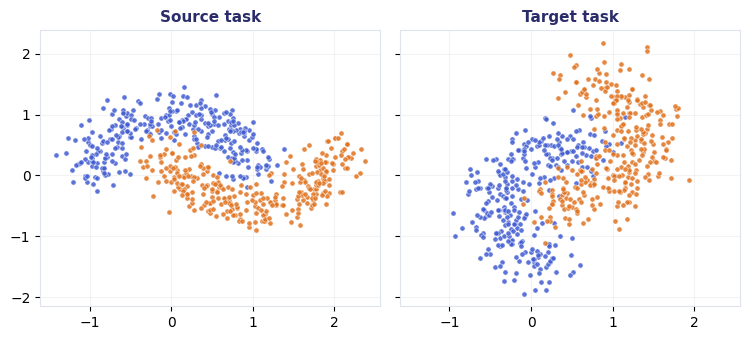

In [10]:
#@title Make Dataset { display-mode: "form" }
def make_task(rotate_deg=0.0, shift=(0.0, 0.0), noise=0.20, n=600, seed=0):
    '''Two moons, optionally rotated and shifted. Same generator for both tasks.'''
    X, y = make_moons(n_samples=n, noise=noise, random_state=seed)
    t = np.radians(rotate_deg)
    R = np.array([[np.cos(t), -np.sin(t)], [np.sin(t), np.cos(t)]])
    X = X @ R.T + np.array(shift)
    return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long)

def split(X, y, n_train=400):
    return X[:n_train], y[:n_train], X[n_train:], y[n_train:]

# SOURCE task - what the backbone is pretrained on
X_src, y_src = make_task(rotate_deg=0.0, shift=(0.0, 0.0), noise=0.20, seed=0)
X_src_train, y_src_train, X_src_test, y_src_test = split(X_src, y_src)

# TARGET task - what every method below has to adapt to
X_tgt, y_tgt = make_task(rotate_deg=75.0, shift=(0.6, -0.5), noise=0.25, seed=1)
X_tgt_train, y_tgt_train, X_tgt_test, y_tgt_test = split(X_tgt, y_tgt)

print("source: %d train / %d test" % (len(X_src_train), len(X_src_test)))
print("target: %d train / %d test" % (len(X_tgt_train), len(X_tgt_test)))
pv.show_tasks(X_src, y_src, X_tgt, y_tgt)

## 1.1 · The model

We use a small neural network with three linear layers and ReLU activations:

```text
2 inputs → Linear(2, 64) → ReLU → Linear(64, 64) → ReLU → Linear(64, 2)

In [11]:
HIDDEN = 64

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, HIDDEN)
        self.fc2 = nn.Linear(HIDDEN, HIDDEN)
        self.fc3 = nn.Linear(HIDDEN, 2)      # the classification head

    def forward(self, x):
        h1 = torch.relu(self.fc1(x))
        h2 = torch.relu(self.fc2(h1))
        return self.fc3(h2)

seed_everything()
demo = MLP()
print(demo)

MLP(
  (fc1): Linear(in_features=2, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=2, bias=True)
)


### 🎯 Task: count the parameters by hand

Before using PyTorch, calculate how many parameters the network contains.

For a `Linear(a, b)` layer:

- the weight matrix has shape `(b, a)`, so it contains $a \times b$ weights;
- the bias vector has length $b$.

Using the architecture above, compute:

1. the number of weights in `nn.Linear(2, 64)`;
2. the number of biases in that layer;
3. the total number of parameters in all three linear layers.

Enter your answers in the boxes below. Each box will immediately tell you whether your count is correct.

In [12]:
#@title Quiz: counting one layer { display-mode: "form" }

pv.number_quiz("layer_math")

In [13]:
#@title Shape NN { display-mode: "form" }
for name, p in demo.fc1.named_parameters():
    print("%-8s shape %-12s %4d elements   requires_grad=%s"
          % (name, tuple(p.shape), p.numel(), p.requires_grad))

weight   shape (64, 2)       128 elements   requires_grad=True
bias     shape (64,)          64 elements   requires_grad=True


In [14]:
#@title Description model { display-mode: "form" }
def describe(model):
    '''Every parameter tensor: name, shape, size, and whether it is being trained.'''
    total, trainable = 0, 0
    for name, p in model.named_parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
        print("%-16s %-14s %6d  %s"
              % (name, tuple(p.shape), p.numel(),
                 "TRAINABLE" if p.requires_grad else "frozen"))
    print("-" * 52)
    print("total     : %6d" % total)
    print("trainable : %6d  (%.2f%% of the model)"
          % (trainable, 100 * trainable / total))

describe(demo)

fc1.weight       (64, 2)           128  TRAINABLE
fc1.bias         (64,)              64  TRAINABLE
fc2.weight       (64, 64)         4096  TRAINABLE
fc2.bias         (64,)              64  TRAINABLE
fc3.weight       (2, 64)           128  TRAINABLE
fc3.bias         (2,)                2  TRAINABLE
----------------------------------------------------
total     :   4482
trainable :   4482  (100.00% of the model)


### 🎯 Task: count total and trainable parameters

Now implement the two parameter counts in code.

| function | what it should return |
|---|---|
| `count_parameters(model)` | the total number of parameter values stored in the model |
| `count_trainable(model)` | the number of parameter values that currently have `requires_grad=True` |

At this point, nothing is frozen yet, so the two counts are identical.

Later, PEFT methods will freeze most of the model, and the difference between these two numbers will become important.

<details>
<summary>💡 <b>Hint 1</b></summary>

`model.parameters()` gives the parameter tensors, and `p.numel()` gives the number of values inside each tensor.

For the trainable count, include only tensors with `p.requires_grad=True`.

</details>

<details>
<summary>🔧 <b>Hint 2</b></summary>

Total parameters:

`sum(p.numel() for p in model.parameters())`

Trainable parameters: use the same sum, but filter on `p.requires_grad`.

</details>

In [15]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters())       # 🎯 every parameter the forward pass needs

def count_trainable(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)        # 🎯 only the ones that get a gradient and an update

print("total    :", count_parameters(demo))
print("trainable:", count_trainable(demo))
assert count_parameters(demo) == 4482, "192 + 4160 + 130 = 4482"
print("✅ 4,482 parameters, of which the middle layer alone is 4,160")

total    : 4482
trainable: 4482
✅ 4,482 parameters, of which the middle layer alone is 4,160


## 1.2 · Pretrain the backbone once

We now train the model on the **source task**.

This cell runs only once. The resulting pretrained weights are then saved and reused as the common starting point for every adaptation method in the rest of the notebook.

Training uses the standard setup:

- full-batch training;
- Adam optimiser;
- cross-entropy loss.

After this point, the pretrained state stays fixed. BitFit, LoRA, Diff Pruning, and full fine-tuning will all start from exactly the same weights.

In [16]:
#@title Pretraining { display-mode: "form" }
def accuracy(model, X, y):
    model.eval()
    with torch.no_grad():
        return (model(X).argmax(dim=1) == y).float().mean().item()

def train(model, X, y, epochs=200, lr=0.01):
    '''Train whatever has requires_grad=True, and report how long it took.'''
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimiser = torch.optim.Adam(trainable, lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    start = time.perf_counter()
    for _ in range(epochs):
        optimiser.zero_grad()
        loss = loss_fn(model(X), y)
        loss.backward()
        optimiser.step()
    return time.perf_counter() - start

seed_everything()
backbone = MLP()
pretrain_time = train(backbone, X_src_train, y_src_train, epochs=400, lr=0.01)

PRETRAINED_STATE = copy.deepcopy(backbone.state_dict())   # the one shared starting point

acc_src_before = accuracy(backbone, X_src_test, y_src_test)
acc_tgt_before = accuracy(backbone, X_tgt_test, y_tgt_test)
print("pretraining took %.2f s" % pretrain_time)
print("source accuracy : %.1f%%" % (100 * acc_src_before))
print("target accuracy : %.1f%%   <- this is what every method below has to fix"
      % (100 * acc_tgt_before))

pretraining took 0.68 s
source accuracy : 97.0%
target accuracy : 44.5%   <- this is what every method below has to fix


The plots below show the decision boundary of the pretrained model on both tasks.

On the **source task**, the boundary correctly separates the two classes because this is the task the model was trained on.

On the **target task**, the same boundary no longer matches the data and cuts through the classes.

This is the adaptation problem the rest of the notebook will try to solve.

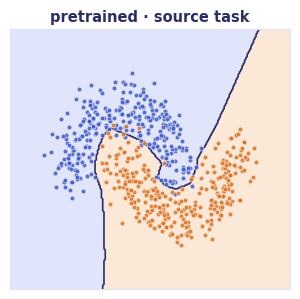

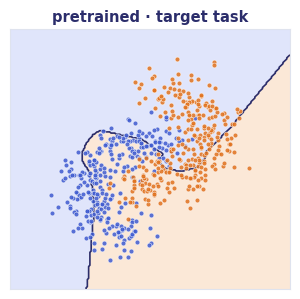

In [17]:
#@title Visualization Prediction { display-mode: "form" }
def predict_fn(model):
    '''A function the plotter can call on a grid of points.'''
    def f(grid):
        model.eval()
        with torch.no_grad():
            return model(torch.tensor(grid)).argmax(dim=1).numpy()
    return f

pv.boundaries([("pretrained · source task", predict_fn(backbone))], X_src, y_src, ncols=1)
pv.boundaries([("pretrained · target task", predict_fn(backbone))], X_tgt, y_tgt, ncols=1)

In [18]:
#@title Map of the pretrained model { display-mode: "form" }
def map_entries(model):
    return [(n, p.numel(), p.requires_grad) for n, p in model.named_parameters()]

pv.model_map(map_entries(backbone), title="The pretrained backbone, nothing frozen yet")

---
# Part 2. Full fine-tuning, the baseline  ·  ~7 min

We start with the most direct way to adapt a pretrained model to a new task: **full fine-tuning**.

We take the pretrained backbone from Part 1, train it on the **target task**, and allow **every weight and bias** in the model to change.

This will be our **baseline**. All later parameter-efficient methods will be compared against it: how much accuracy they retain, how much memory they use, how large their task-specific checkpoint is, and how long they take to train.

For every method, we keep three different costs separate:

| quantity | what it means |
|---|---|
| **training state** | memory needed during training for model parameters, gradients, and optimiser state |
| **task checkpoint** | how much task-specific information must be saved after training |
| **runtime** | how much computation is required during training |

These quantities measure different things. For example, a method may save a very small checkpoint while still requiring substantial computation during training.

The goal of this notebook is therefore not just to count trainable parameters, but to compare these different efficiency costs separately.

## 2.1 · Estimate the training-state memory

Before comparing fine-tuning methods, we need a simple way to estimate how much memory their **training state** requires.

Assume FP32, so each stored number uses **4 bytes**, and an Adam-style optimiser, which stores **two additional values** for every trainable parameter.

For each parameter, we may need to store:

- **parameter value:** 4 bytes for **every** parameter, including frozen ones;
- **gradient:** 4 bytes for **trainable parameters only**;
- **Adam moments:** 8 bytes for **trainable parameters only**, because Adam stores two FP32 values per optimised parameter.

Therefore,

$$
M_{\text{estimated}}
=
4N_{\text{total}}
+
4N_{\text{trainable}}
+
8N_{\text{trainable}}.
$$

The important distinction is that **frozen parameters still have to be stored and used in the forward pass**, even though we do not compute optimiser updates for them.

> ⚠️ **This is only a simplified estimate.**
>
> It does **not** include activations, temporary buffers, framework overhead, or other intermediate values used during training. Therefore, reducing the number of trainable parameters does not necessarily reduce total training memory by the same percentage.

### 🎯 Task: implement the estimate

Complete `training_state_bytes` by translating the three terms above into code.

| variable | what it should count |
|---|---|
| `weights` | one stored value for every parameter |
| `gradients` | one gradient for every trainable parameter |
| `optimiser` | Adam's two stored moments for every trainable parameter |

Use `bytes_per_param` instead of hardcoding `4`, so the same function also works with a different numerical precision.

The `assert` statements below will test your implementation in two cases: first when the whole model is trainable, and then when only 130 parameters are trainable.

<details>
<summary>💡 <b>Hint 1</b>: which parameters contribute to each term?</summary>

`weights` depends on `n_total`, because frozen parameters must still be stored.

`gradients` and `optimiser` depend on `n_trainable`, because they are only needed for parameters that are being updated.

</details>

<details>
<summary>🔧 <b>Hint 2</b>: translate the formula directly</summary>

The three terms correspond to:

`bytes_per_param * n_total`

`bytes_per_param * n_trainable`

`2 * bytes_per_param * n_trainable`

</details>

In [19]:
def training_state_bytes(n_total, n_trainable, bytes_per_param=4):
    weights   = bytes_per_param * n_total      # 🎯 every parameter has to be stored
    gradients = bytes_per_param * n_trainable      # 🎯 one gradient per trainable parameter
    optimiser = 2 * bytes_per_param * n_trainable      # 🎯 Adam keeps TWO moments per trainable parameter
    return weights + gradients + optimiser

# a quick sanity check on the model you already have
print("all 4482 trainable :", training_state_bytes(4482, 4482), "bytes")
print("only 130 trainable :", training_state_bytes(4482, 130), "bytes")
assert training_state_bytes(4482, 4482) == 4482 * 16
assert training_state_bytes(4482, 130) == 4482 * 4 + 130 * 12
print("✅ freezing shrinks two of the three terms, and leaves the first one alone")

all 4482 trainable : 71712 bytes
only 130 trainable : 19488 bytes
✅ freezing shrinks two of the three terms, and leaves the first one alone


In [20]:
#@title Saving Checkpoints { display-mode: "form" }

import tempfile
CKPT_DIR = tempfile.mkdtemp(prefix="peft_ckpt_")

def checkpoint_bytes(tensors, name):
    '''Save exactly these tensors, then ask the filesystem how big the file is.'''
    path = os.path.join(CKPT_DIR, name + ".pt")
    torch.save(tensors, path)
    return os.path.getsize(path)

def inference_ms(model, X, repeats=200, warmup=20):
    model.eval()
    with torch.no_grad():
        for _ in range(warmup):
            model(X)
        start = time.perf_counter()
        for _ in range(repeats):
            model(X)
    return (time.perf_counter() - start) / repeats * 1000

def measure(method, model, train_time, ckpt, trainable_override=None,
            train_state_override=None, **flags):
    '''One row of the comparison. Nothing is estimated except the memory figure.

    The two overrides exist for one method only (Diff Pruning in Part 5), where
    what is trained and what is served are not the same object.
    '''
    total = count_parameters(model)
    trainable = trainable_override or count_trainable(model)
    record = {
        "method": method,
        "total_params": total,
        "trainable_params": trainable,
        "train_state_bytes": train_state_override or training_state_bytes(total, trainable),
        "ckpt_bytes": ckpt,
        "target_acc": accuracy(model, X_tgt_test, y_tgt_test),
        "source_acc": accuracy(model, X_src_test, y_src_test),
        "train_time_s": train_time,
        "infer_ms": inference_ms(model, X_tgt_test),
    }
    record.update(flags)
    return record

results = []      # every method appends one record here
print("checkpoints will be written to", CKPT_DIR)

checkpoints will be written to /tmp/peft_ckpt_iszdyrcd


## 2.2 · Fine-tune everything

We now adapt the pretrained model to the **target task** using full fine-tuning.

We start from the pretrained weights, unfreeze **all** model parameters, and train on the target-task data for 200 epochs using Adam with learning rate `0.01`.

This means that every weight and bias in the pretrained model is allowed to change.

In [21]:
#@title Full Fine-tuning Baseline { display-mode: "form" }

def fresh_backbone():
    '''An exact copy of the pretrained model. Every method starts here.'''
    model = MLP()
    model.load_state_dict(copy.deepcopy(PRETRAINED_STATE))
    return model

seed_everything()
full_model = fresh_backbone()

for p in full_model.parameters():
    p.requires_grad = True                      # the baseline trains everything

total, trainable = count_parameters(full_model), count_trainable(full_model)
print("total %d · trainable %d (%.1f%%)" % (total, trainable, 100 * trainable / total))

full_time = train(full_model, X_tgt_train, y_tgt_train, epochs=200, lr=0.01)
print("trained in %.2f s" % full_time)
print("target accuracy: %.1f%%  (was %.1f%% before adapting)"
      % (100 * accuracy(full_model, X_tgt_test, y_tgt_test), 100 * acc_tgt_before))

total 4482 · trainable 4482 (100.0%)
trained in 0.32 s
target accuracy: 91.5%  (was 44.5% before adapting)


### Which parameters are trainable?

In full fine-tuning, **every parameter in the pretrained model is trainable**.

That means gradients are computed for all weights and biases, and Adam is allowed to update the entire model while learning the target task.

So, for full fine-tuning,

$$
N_{\text{trainable}} = N_{\text{total}}.
$$

In [22]:
#@title Baseline Checkpoint and Dashboard { display-mode: "form" }

full_ckpt = checkpoint_bytes(full_model.state_dict(), "full_finetuning")
print("task checkpoint:", full_ckpt, "bytes")

full_record = measure("Full fine-tuning", full_model, full_time, full_ckpt,
                      changes_path=False, mergeable=False, shares_backbone=False,
                      advantage="Every parameter is free to move",
                      limitation="A complete training state and a complete checkpoint per task")
results.append(full_record)
BASELINE = full_record          # every later dashboard is a percentage of this one

pv.dashboard(full_record)

task checkpoint: 20981 bytes


### What do we need to save for this task?

After full fine-tuning, the whole model has potentially changed.

Therefore, to use this task-specific model again, we need to save the **entire set of fine-tuned parameters**.

So the task checkpoint is essentially a complete copy of the model.

This is one of the main costs of full fine-tuning: if we fine-tune the same backbone for many different tasks, we need to store a full model checkpoint for each task.

In [23]:
#@title Parameter Strip { display-mode: "form" }

pv.param_strip(full_record["total_params"], full_record["trainable_params"],
               title="Full fine-tuning · nothing is frozen")

### Where does the training-state memory come from?

Because every parameter is trainable, every parameter contributes not only its stored value, but also a gradient and Adam's two optimiser moments.

For full fine-tuning,

$$
M_{\text{estimated}}
=
4N + 4N + 8N
=
16N.
$$

Only the first $4N$ bytes are the model parameters themselves.

The remaining

$$
4N + 8N = 12N
$$

bytes come from the **gradients and Adam state** required because we are optimising every parameter.

So, in this simplified estimate, **three quarters of the training state comes from optimisation-related state**, not from storing the model itself.

In [24]:
#@title Memory Breakdown { display-mode: "form" }

pv.memory_stack(full_record["total_params"], full_record["trainable_params"])

### 🧠 Quick check
Click every statement you think is **true**.

In [25]:
#@title Quick Check { display-mode: "form" }

pv.true_false_quiz("counting")

---
# Part 3. BitFit: train only the biases  ·  ~6 min

Our first parameter-efficient fine-tuning method is **BitFit**.

Instead of updating the whole pretrained model, BitFit freezes all weight matrices and trains only the **bias vectors that are already present in the network**.

So the model structure does not change:

- no new layers are added;
- no new parameters are introduced;
- the forward pass stays exactly the same.

The only difference is that gradients are computed only for the bias terms.

In other words, full fine-tuning updates

$$
\text{weights} + \text{biases},
$$

while BitFit updates only

$$
\text{biases}.
$$

This makes BitFit extremely small: the adaptation for the target task is represented only by the bias values that changed.

> 🧷 **Policy used throughout this notebook**
>
> To make the PEFT methods comparable, the classification weight matrix `fc3.weight` is always kept frozen.
>
> Otherwise, a method could improve performance simply by retraining the final classifier instead of relying on its own adaptation mechanism.
>
> BitFit is the only special case for the classification head: `fc3.bias` is trainable, because BitFit is specifically defined as training bias parameters.
>
> Therefore, for BitFit:
>
> - `fc3.weight` → frozen
> - `fc3.bias` → trainable
>
> The same frozen-head-weight policy will be used for all PEFT methods that follow.

## 3.1 · Freeze everything, then unfreeze the biases

BitFit changes only the **bias parameters** of the pretrained model.

We implement this in two steps:

1. freeze every parameter in the network;
2. unfreeze only the parameters whose name corresponds to a bias.

This pattern will also be used for the PEFT methods that follow: first freeze the pretrained backbone, then enable gradients only for the parameters that define the adaptation method.

### 🎯 Task: select the BitFit parameters

The cell below already freezes the full model.

Your job is to complete the condition that identifies the parameters BitFit is allowed to train.

PyTorch names parameters using the pattern

`<layer>.<parameter>`

for example:

- `fc1.weight`
- `fc1.bias`
- `fc2.weight`
- `fc2.bias`

BitFit trains only the parameters ending in `bias`.

If your condition is correct, the model will have **130 trainable parameters out of 4,482**.

<details>
<summary>💡 <b>Hint 1</b>: what should the condition detect?</summary>

Look at the parameter name stored in `name`.

You want the condition to be true only when that name corresponds to a bias parameter.

</details>

<details>
<summary>🔧 <b>Hint 2</b>: which method can you use?</summary>

Use:

`name.endswith("bias")`

When the condition is true, set:

`p.requires_grad = True`

</details>

In [27]:
seed_everything()
bitfit_model = fresh_backbone()

for p in bitfit_model.parameters():          # step 1: freeze the entire model
    p.requires_grad = False

for name, p in bitfit_model.named_parameters():
    if name.endswith("bias"):                                  # 🎯 which parameters does BitFit train?
        p.requires_grad = True

describe(bitfit_model)

fc1.weight       (64, 2)           128  frozen
fc1.bias         (64,)              64  TRAINABLE
fc2.weight       (64, 64)         4096  frozen
fc2.bias         (64,)              64  TRAINABLE
fc3.weight       (2, 64)           128  frozen
fc3.bias         (2,)                2  TRAINABLE
----------------------------------------------------
total     :   4482
trainable :    130  (2.90% of the model)


64 + 64 + 2 = 130 numbers, out of 4,482. Here is the same fact as a map: the weight
matrices stay grey, the thin bias strips turn orange.

In [28]:
#@title Map: what BitFit trains { display-mode: "form" }

pv.model_map(map_entries(bitfit_model),
             title="BitFit · the weight matrices never move")

## 3.2 · Train and measure

We now train BitFit on the **same target data** and with the **same training setup** as full fine-tuning: 200 epochs of Adam with learning rate `0.01`.

The only difference is that Adam now receives **only the bias parameters**.

This keeps the comparison fair: same task, same optimiser, same training budget, only the trainable parameters change.

In [29]:
#@title BitFit training run { display-mode: "form" }

bitfit_time = train(bitfit_model, X_tgt_train, y_tgt_train, epochs=200, lr=0.01)
print("trained in %.2f s  (full fine-tuning took %.2f s)" % (bitfit_time, full_time))

trained in 0.24 s  (full fine-tuning took 0.32 s)


### 🎯 Task: save only the task-specific parameters

With PEFT, we do **not** save the whole model again.

The pretrained backbone is frozen and can be stored once and shared across tasks. For each new task, we only need to save the parameters that were actually trained.

So `task_checkpoint(model)` should return a dictionary containing:

- the name of each **trainable** parameter;
- its corresponding tensor.

Frozen parameters must be excluded.

The cell then saves this dictionary to disk and compares its size with the full fine-tuning checkpoint.

<details>
<summary>💡 <b>Hint 1</b>: which parameters belong in the checkpoint?</summary>

Only parameters with:

`p.requires_grad == True`


In [30]:
def task_checkpoint(model):
    '''Only the parameters this task actually changed.'''
    return {name: p.detach().clone()
            for name, p in model.named_parameters()
            if p.requires_grad}              # 🎯 which parameters belong in this task's checkpoint?

bitfit_state = task_checkpoint(bitfit_model)
bitfit_ckpt = checkpoint_bytes(bitfit_state, "bitfit")

print("saved tensors:", list(bitfit_state.keys()))
print("checkpoint: %d bytes  (full fine-tuning: %d bytes)" % (bitfit_ckpt, full_ckpt))

saved tensors: ['fc1.bias', 'fc2.bias', 'fc3.bias']
checkpoint: 2456 bytes  (full fine-tuning: 20981 bytes)


In [31]:
#@title BitFit record and dashboard { display-mode: "form" }

bitfit_record = measure("BitFit", bitfit_model, bitfit_time, bitfit_ckpt,
                        changes_path=False, mergeable=True,
                        advantage="Nothing is added to the model at all",
                        limitation="Very little capacity: biases shift outputs, they cannot "
                                   "reshape what a layer computes")
results.append(bitfit_record)

pv.dashboard(bitfit_record, baseline=BASELINE)

Look at the four bars before reading on.

BitFit dramatically reduces the number of **trainable parameters** and the **task checkpoint size**, because only the bias vectors are updated and saved.

The **training-state memory** decreases much less: even though most parameters are frozen, the entire pretrained model still has to be stored in memory to perform the forward pass.

The **training time** changes even less. Freezing a parameter means that we do not update it, but the frozen backbone still participates in every forward pass, and backpropagation must still propagate gradients through the network to reach the trainable biases.

So BitFit makes the **task-specific adaptation very small**, but it does not make the underlying model disappear.

The decision boundary obtained with this small adaptation is shown below:

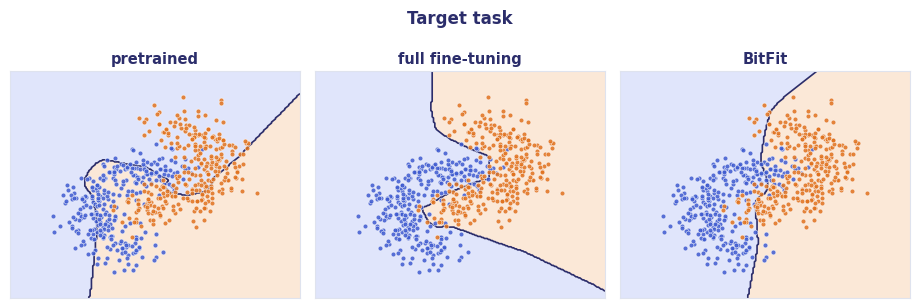

In [32]:
#@title Decision boundaries after BitFit { display-mode: "form" }

pv.boundaries([("pretrained", predict_fn(backbone)),
               ("full fine-tuning", predict_fn(full_model)),
               ("BitFit", predict_fn(bitfit_model))],
              X_tgt, y_tgt, title="Target task")

### 🧠 Quick check

In [33]:
#@title Quiz: the frozen forward pass { display-mode: "form" }

pv.mc_quiz("frozen_forward")

---
# Part 4. LoRA: learn a small update instead of changing the whole weight matrix  ·  ~11 min

To understand LoRA, focus on a single linear layer:

$$
y = Wx + b,
\qquad
W \in \mathbb{R}^{d_{out}\times d_{in}}.
$$

With full fine-tuning, the pretrained matrix $W$ is allowed to change freely. We can think of the new weight matrix as

$$
W_{\text{new}} = W + \Delta W,
$$

where $\Delta W$ is a full matrix with

$$
d_{out}d_{in}
$$

trainable entries.

LoRA keeps the pretrained matrix $W$ **frozen** and learns only the update $\Delta W$.

The key idea is to assume that the update needed for a new task can be represented with a much smaller number of parameters:

$$
\Delta W = BA,
$$

with

$$
A \in \mathbb{R}^{r\times d_{in}},
\qquad
B \in \mathbb{R}^{d_{out}\times r},
$$

where the rank $r$ is chosen to be small.

The adapted layer therefore becomes

$$
y = Wx + \frac{\alpha}{r}BAx + b.
$$

You can think of this as two parallel paths:

- $Wx$: the original pretrained transformation, which stays frozen;
- $BAx$: a small trainable correction for the target task.

Instead of learning $d_{out}d_{in}$ update parameters, LoRA learns only

$$
r(d_{in}+d_{out}).
$$

So the smaller the rank $r$, the smaller the task-specific adaptation.

Importantly, LoRA does **not** make $W$ low-rank. The pretrained matrix remains unchanged and full-size. Only the **update** $\Delta W$ is constrained to have low rank.

The factor $\alpha/r$ simply scales the LoRA update.

Finally, $B$ is initialised to zero. At the start of training,

$$
BA = 0,
$$

so the LoRA model behaves exactly like the original pretrained model. Training then gradually learns the task-specific correction.

Move the rank below and observe how changing $r$ changes the shapes of $A$ and $B$, and therefore the number of trainable parameters.

In [34]:
#@title LoRA rank widget { display-mode: "form" }

pv.lora_widget(d_in=HIDDEN, d_out=HIDDEN, ranks=(1, 2, 4, 8, 16), default=4)

### 🎯 Task: compare the update sizes

Before implementing LoRA, calculate how many parameters it saves for the layer `fc2`.

For this layer,

$$
d_{in} = 64,
\qquad
d_{out} = 64,
\qquad
r = 4.
$$

Compute these three quantities:

1. **Full fine-tuning:** how many parameters would a complete update matrix $\Delta W$ contain?

$$
d_{out}d_{in}
$$

2. **LoRA:** how many trainable parameters are contained in $A$ and $B$ together?

$$
r(d_{in}+d_{out})
$$

3. **Reduction factor:** how many times fewer parameters does LoRA train compared with a full update?

$$
\frac{d_{out}d_{in}}{r(d_{in}+d_{out})}
$$

Enter the three numerical answers in the boxes below.

In [35]:
#@title Quiz: LoRA arithmetic { display-mode: "form" }

pv.number_quiz("lora_math")

## 4.1 · Add LoRA to one layer

We apply LoRA only to `fc2`, the $64 \times 64$ hidden layer.

The original `fc2` weights and bias remain **frozen**. The other layers, `fc1` and `fc3`, are also left unchanged.

The only trainable parameters are the two LoRA matrices:

$$
A \in \mathbb{R}^{r \times 64},
\qquad
B \in \mathbb{R}^{64 \times r}.
$$

### 🎯 Task: implement the LoRA update

The pretrained output of `fc2` is already computed for you:

$$
\text{frozen\_part} = Wh_1 + b.
$$

Your task is to implement the additional LoRA branch

$$
\text{lora\_part}
=
\frac{\alpha}{r}BAh_1,
$$

and add it to the frozen output.

Conceptually, the LoRA branch does three things:

1. $A$ maps the 64-dimensional activation down to $r$ dimensions;
2. $B$ maps those $r$ values back to 64 dimensions;
3. the result is scaled by $\alpha/r$.

Because `h1` contains row vectors in a batch, the corresponding PyTorch computation uses the transposes of $A$ and $B$.

If your implementation is correct:

- only **512 parameters** are trainable when $r=4$;
- the model initially behaves exactly like the pretrained model, because $B$ starts at zero.

<details>
<summary>💡 <b>Hint 1</b>: follow the dimensions</summary>

Starting from

`h1`: `(batch, 64)`

first apply $A$:

`(batch, 64) @ (64, r) → (batch, r)`

then apply $B$:

`(batch, r) @ (r, 64) → (batch, 64)`

</details>

<details>
<summary>🔧 <b>Hint 2</b>: translate the formula</summary>

Use:

`(self.alpha / self.r) * (h1 @ self.A.T) @ self.B.T`

</details>

In [36]:
class LoRAMLP(nn.Module):
    def __init__(self, state, r=4, alpha=8.0):
        super().__init__()
        self.backbone = MLP()
        self.backbone.load_state_dict(copy.deepcopy(state))
        for p in self.backbone.parameters():
            p.requires_grad = False                       # W stays exactly as pretrained

        self.r, self.alpha = r, alpha
        self.A = nn.Parameter(torch.randn(r, HIDDEN) * 0.01)   # (r, d_in)
        self.B = nn.Parameter(torch.zeros(HIDDEN, r))          # (d_out, r), starts at zero

    def forward(self, x):
        bb = self.backbone
        h1 = torch.relu(bb.fc1(x))
        frozen_part = bb.fc2(h1)                                    # W h1 + b
        lora_part   = (self.alpha / self.r) * (h1 @ self.A.T) @ self.B.T # 🎯 the (alpha/r) B A h1 branch
        h2 = torch.relu(frozen_part + lora_part)
        return bb.fc3(h2)

seed_everything()
lora_model = LoRAMLP(PRETRAINED_STATE, r=4, alpha=8.0)
describe(lora_model)

A                (4, 64)           256  TRAINABLE
B                (64, 4)           256  TRAINABLE
backbone.fc1.weight (64, 2)           128  frozen
backbone.fc1.bias (64,)              64  frozen
backbone.fc2.weight (64, 64)         4096  frozen
backbone.fc2.bias (64,)              64  frozen
backbone.fc3.weight (2, 64)           128  frozen
backbone.fc3.bias (2,)                2  frozen
----------------------------------------------------
total     :   4994
trainable :    512  (10.25% of the model)


512 trainable numbers, standing in for a 4,096-entry update. Check the starting point
first, then train.

In [37]:
#@title LoRA starts as the pretrained model, then trains { display-mode: "form" }

with torch.no_grad():
    same = torch.allclose(lora_model(X_tgt_test), backbone(X_tgt_test), atol=1e-6)
print("B = 0, so the LoRA model starts out as the pretrained model:", same)

lora_time = train(lora_model, X_tgt_train, y_tgt_train, epochs=200, lr=0.01)
print("trained in %.2f s · target accuracy %.1f%%"
      % (lora_time, 100 * accuracy(lora_model, X_tgt_test, y_tgt_test)))

B = 0, so the LoRA model starts out as the pretrained model: True
trained in 0.21 s · target accuracy 91.0%


## 4.2 · What the rank buys

Now we repeat the same LoRA adaptation with five different ranks.

Everything else stays fixed: the same pretrained model, target data, optimiser, and training setup.

Only the rank $r$ changes.

This lets us see the trade-off directly: a larger rank gives LoRA more trainable parameters and a more expressive update, while a smaller rank makes the adaptation cheaper and more constrained.

r=1   trainable   128   target 91.0%   0.20 s
r=2   trainable   256   target 91.0%   0.22 s
r=4   trainable   512   target 91.0%   0.22 s
r=8   trainable  1024   target 91.0%   0.22 s
r=16  trainable  2048   target 91.0%   0.22 s


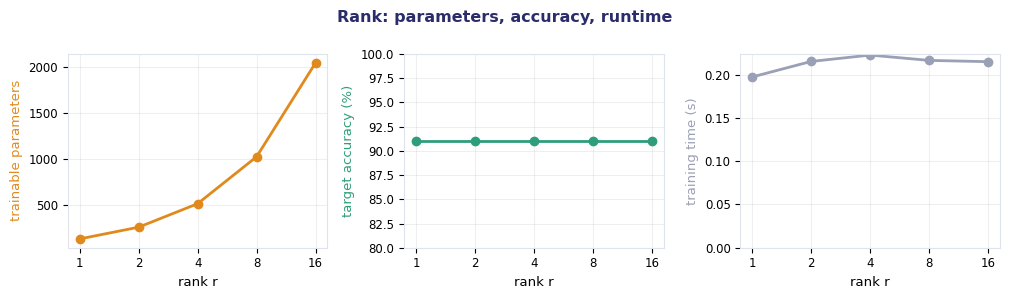

In [38]:
#@title LoRA rank sweep { display-mode: "form" }

ranks = (1, 2, 4, 8, 16)
lora_sweep = {}
for r in ranks:
    seed_everything()
    m = LoRAMLP(PRETRAINED_STATE, r=r, alpha=8.0)
    t = train(m, X_tgt_train, y_tgt_train, epochs=200, lr=0.01)
    lora_sweep[r] = {"trainable": count_trainable(m),
                     "target_acc": accuracy(m, X_tgt_test, y_tgt_test),
                     "time": t, "model": m}
    print("r=%-3d trainable %5d   target %.1f%%   %.2f s"
          % (r, lora_sweep[r]["trainable"], 100 * lora_sweep[r]["target_acc"], t))

pv.sweep_plot(list(ranks),
              [("trainable parameters", [lora_sweep[r]["trainable"] for r in ranks], pv.TRAIN),
               ("target accuracy (%)", [100 * lora_sweep[r]["target_acc"] for r in ranks],
                pv.GREEN, (80, 100)),
               ("training time (s)", [lora_sweep[r]["time"] for r in ranks], pv.GREY, (0, None))],
              xlabel="rank r", title="Rank: parameters, accuracy, runtime", logx=True)

pv.lora_widget(d_in=HIDDEN, d_out=HIDDEN, ranks=ranks, default=4,
               measured={r: {"trainable": v["trainable"], "target_acc": v["target_acc"]}
                         for r, v in lora_sweep.items()})

Read the middle panel carefully.

For this simple two-dimensional target task, even **rank $r=1$** already provides enough capacity to learn the required update. As a result, the accuracy stays almost unchanged as the rank increases, even though the number of trainable parameters grows by a factor of 16.

This flat accuracy curve is specific to **this toy problem**. The general lesson is the trade-off:

- increasing $r$ gives LoRA a more expressive update;
- the number of trainable parameters grows **linearly** with $r$.

The third panel shows another important point. Training time barely changes as the rank increases.

Even though the number of trainable LoRA parameters grows substantially, most of the computation still comes from running the frozen backbone at every training step. On this small model, the extra LoRA computation is too small to have a noticeable effect on runtime.

## 4.3 · Merging LoRA

After training, the LoRA update can be folded into the original weight matrix:

$$
W_{\text{merged}} = W + \frac{\alpha}{r}BA.
$$

So

$$
Wx + \frac{\alpha}{r}BAx
=
W_{\text{merged}}x.
$$

This means the separate LoRA branch is no longer needed at inference time: the served model is again a standard linear layer.

The merge works because the LoRA correction is **linear**. If a nonlinearity were inserted inside the LoRA branch, it could no longer be represented by a single matrix.

The cell below performs the merge and checks numerically that the model output does not change.

In [39]:
#@title Merge the rank-4 update into the backbone { display-mode: "form" }

lora_model = lora_sweep[4]["model"]
lora_time  = lora_sweep[4]["time"]

merged_model = fresh_backbone()
with torch.no_grad():
    delta_W = (lora_model.alpha / lora_model.r) * (lora_model.B @ lora_model.A)  # (64, 64)
    merged_model.fc2.weight += delta_W

lora_model.eval(); merged_model.eval()
with torch.no_grad():
    gap = (lora_model(X_tgt_test) - merged_model(X_tgt_test)).abs().max().item()

print("delta_W shape:", tuple(delta_W.shape), " built from", lora_model.A.numel(),
      "+", lora_model.B.numel(), "trained numbers")
print("largest difference between the two models' outputs: %.2e" % gap)
print("same accuracy: %.1f%% vs %.1f%%"
      % (100 * accuracy(lora_model, X_tgt_test, y_tgt_test),
         100 * accuracy(merged_model, X_tgt_test, y_tgt_test)))
assert gap < 1e-4, "merging must reproduce the branched model up to float32 tolerance"
print("✅ identical up to floating-point tolerance")

delta_W shape: (64, 64)  built from 256 + 256 trained numbers
largest difference between the two models' outputs: 1.91e-06
same accuracy: 91.0% vs 91.0%
✅ identical up to floating-point tolerance


In [40]:
#@title Inference timing { display-mode: "form" }

print("pretrained backbone : %.3f ms" % inference_ms(backbone, X_tgt_test))
print("LoRA, branch active : %.3f ms" % inference_ms(lora_model, X_tgt_test))
print("LoRA, merged        : %.3f ms" % inference_ms(merged_model, X_tgt_test))

pretrained backbone : 0.086 ms
LoRA, branch active : 0.157 ms
LoRA, merged        : 0.089 ms


> 🧷 **Merging is a deployment choice.**
>
> During training and storage, we keep the small LoRA matrices $A$ and $B$ as the task-specific checkpoint.
>
> When loading a task for inference, we can merge them into a copy of the pretrained weight:
>
> $$
> W_{\text{merged}} = W + \frac{\alpha}{r}BA.
> $$
>
> After merging, that model copy is specific to that task. The advantage of keeping $A$ and $B$ separately is that the same pretrained backbone can be reused with many different LoRA checkpoints.

Now compare LoRA with the previous methods in the dashboard. For LoRA, the **task checkpoint contains only $A$ and $B$**, while the pretrained backbone is stored separately and shared.

In [41]:
#@title LoRA checkpoint and dashboard { display-mode: "form" }

lora_ckpt = checkpoint_bytes(task_checkpoint(lora_model), "lora_r4")
print("LoRA checkpoint:", lora_ckpt, "bytes")

lora_record = measure("LoRA", lora_model, lora_time, lora_ckpt,
                      changes_path=False, mergeable=True,
                      advantage="Small, mergeable task update with a capacity dial",
                      limitation="Rank and target layers are choices you have to make")
results.append(lora_record)

pv.dashboard(lora_record, baseline=BASELINE)

LoRA checkpoint: 3813 bytes


The `changes the execution path` tag is **no** because LoRA can be merged into the original weight matrix before deployment.

After merging,

$$
W_{\text{merged}} = W + \frac{\alpha}{r}BA,
$$

the separate LoRA branch disappears, so the served model has the **same architecture and execution path as the original model**.

The inference time shown on the card is instead measured on the **unmerged LoRA model**. In that case, the extra $A \rightarrow B$ branch is still executed, so its inference overhead is included.

### 🧠 Quick check

In [42]:
#@title Quiz: counting LoRA parameters { display-mode: "form" }

pv.mc_quiz("lora_count")

---
# Part 5. Diff Pruning: learn a sparse update  ·  ~7 min

Diff Pruning starts from the same idea as full fine-tuning: the target task needs a change to the pretrained parameters.

Instead of modifying the pretrained parameters directly, we write

$$
\theta_{\text{task}}
=
\theta_{\text{base}} + \Delta\theta,
$$

where the pretrained parameters $\theta_{\text{base}}$ stay frozen and only the difference
$\Delta\theta$ is trained.

The goal is to make $\Delta\theta$ **sparse**: most of its entries should become exactly zero.
Then, for each task, we only need to save the few parameter changes that remain non-zero.

In this notebook we use a simplified version of Diff Pruning:

1. create a trainable difference tensor $\Delta\theta$ for every parameter we want to adapt;
2. train these differences with an **L1 penalty**, which encourages small values;
3. after training, **threshold** the differences: values below a chosen cutoff are set exactly to zero;
4. store only the remaining non-zero updates as the task-specific checkpoint.

> ⚠️ **Small checkpoint does not mean cheap training.**
>
> During training, $\Delta\theta$ is still a dense tensor: there is one trainable difference value,
> together with its gradient and Adam state, for every adapted parameter.
>
> Sparsity only appears **after thresholding**. This is why we report the dense training-state cost
> and the final sparse checkpoint size separately.

In [43]:
#@title Training { display-mode: "form" }
import torch.nn.functional as F

class DiffPruned(nn.Module):
    def __init__(self, state):
        super().__init__()
        self.backbone = MLP()
        self.backbone.load_state_dict(copy.deepcopy(state))
        for p in self.backbone.parameters():
            p.requires_grad = False
        # one trainable difference per base parameter; ParameterDict keys cannot hold dots
        self.delta = nn.ParameterDict({
            name.replace(".", "_"): nn.Parameter(torch.zeros_like(p))
            for name, p in self.backbone.named_parameters()})

    def effective(self, name):
        '''base + difference, for one parameter tensor'''
        base = dict(self.backbone.named_parameters())[name]
        return base + self.delta[name.replace(".", "_")]

    def forward(self, x):
        h1 = torch.relu(F.linear(x, self.effective("fc1.weight"), self.effective("fc1.bias")))
        h2 = torch.relu(F.linear(h1, self.effective("fc2.weight"), self.effective("fc2.bias")))
        return F.linear(h2, self.effective("fc3.weight"), self.effective("fc3.bias"))

def train_with_l1(model, X, y, epochs=200, lr=0.01, l1=0.01):
    '''The usual loop, plus a penalty on the size of the differences.'''
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimiser = torch.optim.Adam(trainable, lr=lr)
    loss_fn = nn.CrossEntropyLoss()
    model.train()
    start = time.perf_counter()
    for _ in range(epochs):
        optimiser.zero_grad()
        penalty = sum(d.abs().sum() for d in model.delta.values())
        loss = loss_fn(model(X), y) + l1 * penalty
        loss.backward()
        optimiser.step()
    return time.perf_counter() - start

seed_everything()
diff_model = DiffPruned(PRETRAINED_STATE)
diff_time = train_with_l1(diff_model, X_tgt_train, y_tgt_train, epochs=200, lr=0.01, l1=0.01)

print("trainable during training:", count_trainable(diff_model),
      "  <- one per base parameter, the same as full fine-tuning")
print("trained in %.2f s · target accuracy %.1f%%"
      % (diff_time, 100 * accuracy(diff_model, X_tgt_test, y_tgt_test)))

trainable during training: 4482   <- one per base parameter, the same as full fine-tuning
trained in 0.53 s · target accuracy 92.5%


## 5.1 · Threshold the update and measure sparsity

After training, the difference tensors $\Delta\theta$ are still dense: most entries may be small, but they are not exactly zero.

We first keep a copy of these **dense learned differences**, so we can compare them with the sparse version.

Then we apply a threshold:

- values smaller than the cutoff are set to zero;
- only the remaining non-zero updates are kept.

This lets us measure how sparse the task-specific update becomes after pruning.

In [44]:
#@title Dense differences, before thresholding { display-mode: "form" }

delta_before = {name: d.detach().clone() for name, d in diff_model.delta.items()}
big = torch.cat([d.flatten().abs() for d in delta_before.values()])
print("differences above 0.05 :", int((big > 0.05).sum()), "of", big.numel())
print("largest difference     : %.3f" % big.max().item())

differences above 0.05 : 75 of 4482
largest difference     : 0.566


The L1 penalty encourages the learned differences to become **small**, but it does not make them exactly zero.

To obtain a truly sparse update, we now apply a hard threshold.

### 🎯 Task: threshold and count the surviving updates

For each trained difference tensor `d`, complete two operations:

1. set every entry whose absolute value is smaller than `THRESHOLD` to exactly zero;
2. count how many entries remain non-zero and add them to `nonzero`.

This is done inside `torch.no_grad()` because we are modifying the trained parameters **after training**, not computing another optimisation step.

The cell then reports how many updates survived pruning and measures the target accuracy again, so we can see how much performance was lost by making the update sparse.

<details>
<summary>💡 <b>Hint 1</b>: what should happen to small values?</summary>

If

`abs(d) < threshold`

that entry should become exactly `0`.

Then count the entries that are still different from zero.

</details>

<details>
<summary>🔧 <b>Hint 2</b>: useful PyTorch expressions</summary>

To threshold in place:

`d[d.abs() < threshold] = 0.0`

To count the surviving entries:

`int((d != 0).sum())`

</details>

In [46]:
THRESHOLD = 0.05

nonzero = 0
with torch.no_grad():
    for name, d in diff_model.delta.items():
        d[d.abs() < THRESHOLD] = 0.0                          # 🎯 zero out every difference smaller than THRESHOLD
        nonzero += int((d != 0).sum())               # 🎯 count the differences that survived

dense = count_trainable(diff_model)
print("differences trained :", dense)
print("still nonzero       :", nonzero, "(%.1f%% of them)" % (100 * nonzero / dense))
print("target accuracy after thresholding: %.1f%%"
      % (100 * accuracy(diff_model, X_tgt_test, y_tgt_test)))

differences trained : 4482
still nonzero       : 75 (1.7% of them)
target accuracy after thresholding: 93.5%


Where did the surviving updates end up?

They are **not spread evenly across the network**. Most of the non-zero differences are concentrated in the first layer, while only a few survive in the much larger `fc2` layer.

So Diff Pruning does not just make the update sparse, it also reveals **where the model actually needed to change** for this target task.

In [47]:
#@title Survivors { display-mode: "form" }
for name, d in diff_model.delta.items():
    print("%-12s %4d of %5d survived" % (name, int((d != 0).sum()), d.numel()))

fc1_bias       21 of    64 survived
fc1_weight     36 of   128 survived
fc2_bias        2 of    64 survived
fc2_weight      2 of  4096 survived
fc3_bias        0 of     2 survived
fc3_weight     14 of   128 survived


After thresholding, the sparse update is highly concentrated.

Most of the surviving changes are in the **first layer**, while `fc2`, despite containing 4,096 of the model’s 4,482 parameters, keeps only a few non-zero updates.

This is consistent with the target task used here: the target moons are a rotated version of the source moons, and changing the first layer is enough to transform the input representation in a useful way.

Importantly, we did not tell the model to modify the first layer. The L1 penalty simply encouraged a sparse solution, and training discovered that concentrating the update there was effective.

The grid below shows the entire learned difference $\Delta\theta$ in parameter order:

- each cell represents one parameter;
- the colour shows the magnitude of its update;
- zero-valued cells correspond to pruned parameters;
- white cells at the end are only padding used to complete the grid.

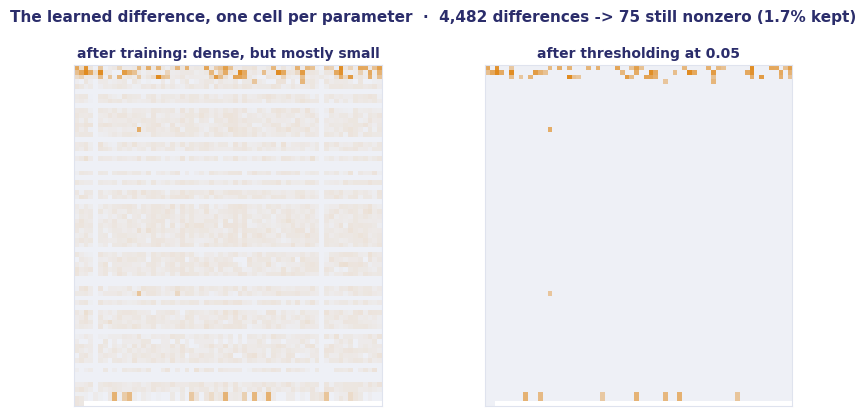

In [48]:
#@title Visualization Weights { display-mode: "form" }
flat_before = torch.cat([d.flatten() for d in delta_before.values()]).numpy()
pv.diff_grid(flat_before, threshold=THRESHOLD)

## 5.2 · The real cost of a sparse checkpoint

A sparse update contains only the non-zero values, but the values alone are not enough.

For each saved update, we also need to record **where it belongs** in the original parameter tensor.

So a sparse checkpoint must store both:

- the surviving update values;
- their positions, using indices or a mask.

This means the checkpoint size depends not only on **how many values survive**, but also on the metadata needed to locate them.

In [49]:
#@title Cost { display-mode: "form" }
flat = torch.cat([d.detach().flatten() for d in diff_model.delta.values()])
positions = torch.nonzero(flat, as_tuple=False).flatten().to(torch.int32)
values    = flat[positions.long()]

sparse_state = {"positions": positions, "values": values}   # where, and how much
diff_ckpt = checkpoint_bytes(sparse_state, "diff_pruning")
estimated = nonzero * (4 + 4)          # 4 bytes per value, 4 per position

print("nonzero values     :", nonzero)
print("estimated payload  : %d bytes  (value + position, 4 bytes each)" % estimated)
print("actual file        : %d bytes  (torch adds dtypes, shapes and pickle framing)" % diff_ckpt)
print("BitFit             : %d bytes" % bitfit_ckpt)
print("full fine-tuning   : %d bytes" % full_ckpt)

nonzero values     : 75
estimated payload  : 600 bytes  (value + position, 4 bytes each)
actual file        : 2445 bytes  (torch adds dtypes, shapes and pickle framing)
BitFit             : 2456 bytes
full fine-tuning   : 20981 bytes


At this scale, the sparse checkpoint is dominated by **file-format overhead** rather than by the update itself.

The actual sparse payload is only about **592 bytes**, while the saved file is a few kilobytes because it also contains metadata, tensor structure, and serialization overhead.

That ratio is specific to this tiny 4,482-parameter model. The overhead is roughly fixed, while the useful payload grows with the size of the adapted model.

For inference, the sparse difference is added back into the pretrained parameters:

$$
\theta_{\text{merged}}
=
\theta_{\text{base}}+\Delta\theta.
$$

After this merge, there is no separate Diff Pruning branch. The deployed model is again a standard MLP with the **same architecture and execution path as the original model**.

The inference time reported below is measured on this merged model.

In [50]:
#@title Sumamry cost { display-mode: "form" }
diff_merged = fresh_backbone()
with torch.no_grad():
    for name, p in diff_merged.named_parameters():
        p += diff_model.delta[name.replace(".", "_")]

# what training cost: the base weights AND a dense difference for each of them
diff_train_state = training_state_bytes(count_parameters(diff_model), count_trainable(diff_model))

diff_record = measure("Diff Pruning", diff_merged, diff_time, diff_ckpt,
                      trainable_override=dense, train_state_override=diff_train_state,
                      changes_path=False, mergeable=True,
                      advantage="A genuinely sparse task update, saved as a short list",
                      limitation="Dense difference variables while training, and a sparse "
                                 "format to maintain afterwards")
results.append(diff_record)

pv.dashboard(diff_record, baseline=BASELINE)

Read this card carefully, because Diff Pruning shows an important distinction.

After thresholding, this task keeps only **74 non-zero updates**, together with their positions. So the task-specific checkpoint is extremely small.

During training, however, the situation was very different. Diff Pruning had to store:

- the frozen base parameters;
- a trainable difference for every adapted parameter;
- one gradient for every difference;
- Adam's two optimiser moments for every difference.

That is why its estimated training state is actually **larger than full fine-tuning**, even though its final checkpoint is much smaller.

> ### What you store after training and what you need in memory during training are different costs.
>
> Diff Pruning makes this distinction especially clear.

### 🧠 Quick check

In [51]:
#@title Quiz: training state versus checkpoint { display-mode: "form" }

pv.mc_quiz("diff_memory")

---
# Part 6. Compare the methods and choose the right trade-off  ·  ~7 min

We have now adapted the **same pretrained model** to the **same target task** using four different strategies.

Each method started from the same pretrained state and used the same training budget, so the comparison is directly about **how the adaptation is represented and what it costs**.

The table below brings together everything measured in the notebook: accuracy, trainable parameters, training-state memory, checkpoint size, and runtime.

The goal is not to find one method that is always best, but to understand **which trade-off each method makes**.

In [52]:
#@title Summary table { display-mode: "form" }
pv.results_table(results,
                 extra="Every row started from the same PRETRAINED_STATE, used the same "
                       "target split, the same optimiser (Adam, lr 0.01), the same 200 epochs "
                       "and full batches. The classification head weight fc3.weight was frozen "
                       "for every PEFT method; BitFit moves its bias, because a bias is what "
                       "BitFit trains.")

Method,Paramsfor inference,Trainableand % of total,Training stateestimate,Taskcheckpoint,Targetacc.,Source acc.after adapting,Traintime,Inference,Pathchanged,Mergeable
Full fine-tuning,"4,482","4,482 (100.00%)",71.7 KB,21.0 KB,91.5%,80.5%,0.32 s,0.171 ms,no,no
BitFit,"4,482",130 (2.90%),19.5 KB,2.5 KB,85.5%,68.0%,0.24 s,0.091 ms,no,yes
LoRA,"4,994",512 (10.25%),26.1 KB,3.8 KB,91.0%,80.0%,0.22 s,0.144 ms,no,yes
Diff Pruning,"4,482","4,482 (100.00%)",89.6 KB,2.4 KB,93.5%,80.5%,0.53 s,0.085 ms,no,yes


## 6.1 · The three costs do not move together

Each group of bars is shown relative to full fine-tuning, which is set to **100%**.

Compare the three efficiency measures carefully:

- trainable parameters;
- training-state memory;
- task checkpoint size.

They do **not** decrease by the same amount.

That is one of the main lessons of the notebook: reducing the number of trainable parameters does not automatically give the same reduction in training memory or checkpoint size.

Different PEFT methods save resources in different ways, so these costs must be evaluated separately.

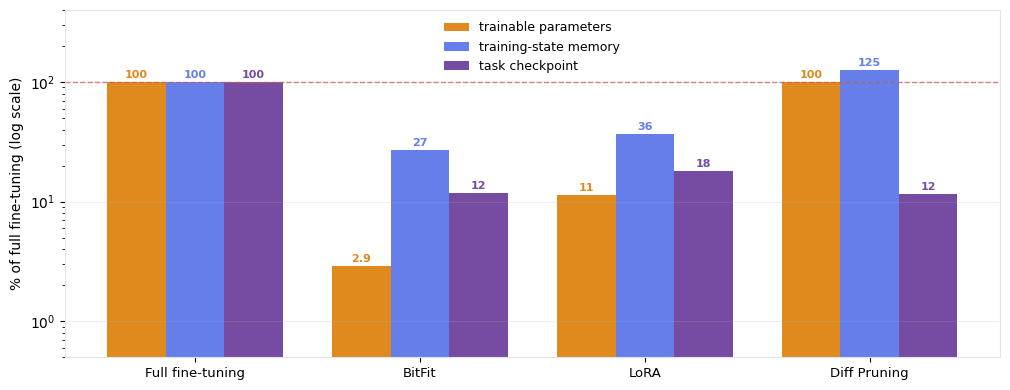

In [53]:
#@title Comparison { display-mode: "form" }
pv.normalised_bars(results, baseline=BASELINE)

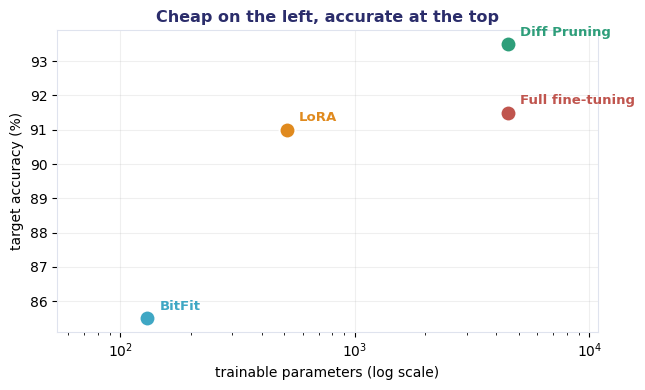

In [54]:
#@title Trainable parameters { display-mode: "form" }
pv.pareto(results)

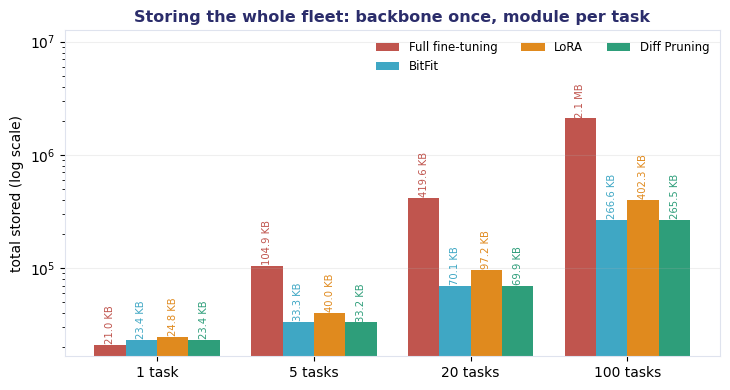

In [55]:
#@title Storing { display-mode: "form" }
pv.storage_projection(results, backbone_bytes=full_ckpt, tasks=(1, 5, 20, 100))

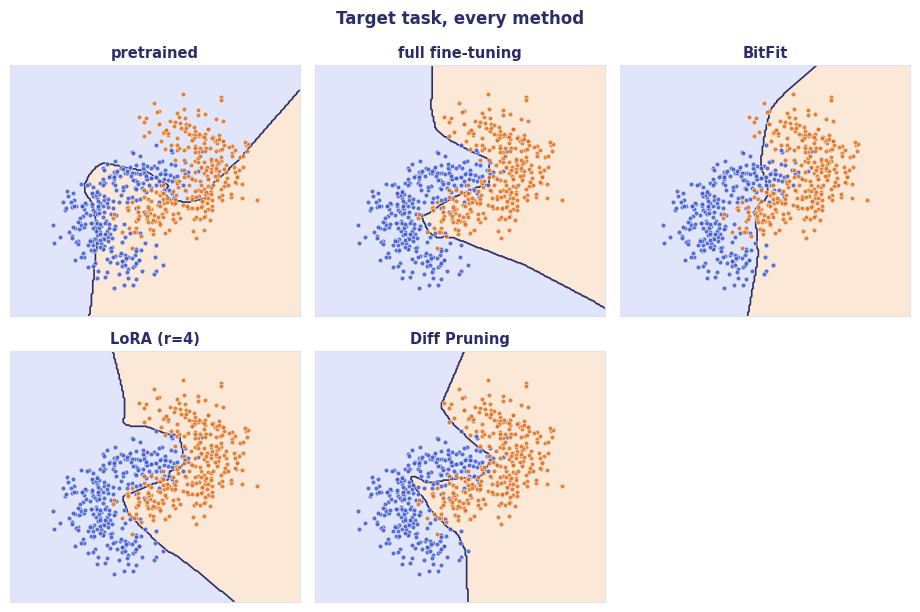

In [56]:
#@title Results on the task { display-mode: "form" }
pv.boundaries([("pretrained", predict_fn(backbone)),
               ("full fine-tuning", predict_fn(full_model)),
               ("BitFit", predict_fn(bitfit_model)),
               ("LoRA (r=4)", predict_fn(lora_model)),
               ("Diff Pruning", predict_fn(diff_merged))],
              X_tgt, y_tgt, title="Target task, every method", ncols=3)

## 6.2 · What happens to the original task?

The PEFT methods keep the pretrained backbone weights frozen, but the **model's behaviour can still change** after adaptation.

Why? Because each method adds or modifies task-specific components, biases, LoRA updates, or sparse differences that also affect predictions when we evaluate the model on the original source task.

So freezing the backbone does **not** guarantee that source-task performance is preserved.

Compare the source accuracy after adaptation with the pretrained model's original source accuracy. This shows how much each method trades off the old task while adapting to the new one.

In [57]:
#@title What each method did to the source task { display-mode: "form" }

print("source accuracy before adapting: %.1f%%\n" % (100 * acc_src_before))
for r in results:
    print("%-16s target %.1f%%   source %.1f%%   (%+.1f points)"
          % (r["method"], 100 * r["target_acc"], 100 * r["source_acc"],
             100 * (r["source_acc"] - acc_src_before)))

source accuracy before adapting: 97.0%

Full fine-tuning target 91.5%   source 80.5%   (-16.5 points)
BitFit           target 85.5%   source 68.0%   (-29.0 points)
LoRA             target 91.0%   source 80.0%   (-17.0 points)
Diff Pruning     target 93.5%   source 80.5%   (-16.5 points)


Freezing the pretrained weights preserves the original model **as stored parameters**, not necessarily its behaviour while a PEFT adaptation is active.

The backbone values stay unchanged, so removing the task-specific adaptation recovers the original pretrained model exactly.

But while the adaptation is attached, the computation is different:

- BitFit uses modified biases;
- LoRA adds a learned low-rank update;
- Diff Pruning adds a learned sparse difference.

So predictions on the original source task can still change.

Freezing may reduce interference with the pretrained model, but it does **not guarantee** preservation of source-task accuracy. The main reason to use PEFT here is efficiency: smaller task-specific updates, not guaranteed retention of the old task.

### 🧠 Quick checks

In [58]:
#@title Quiz: speed-up { display-mode: "form" }

pv.mc_quiz("speedup")

In [59]:
#@title Quiz: forgetting { display-mode: "form" }

pv.mc_quiz("forgetting")

In [60]:
#@title Quiz: systems { display-mode: "form" }

pv.true_false_quiz("systems")

---
# Part 7. The same ideas on large pretrained models  ·  ~2 min

So far, we have applied PEFT to a tiny MLP with only three linear layers.

Large pretrained models contain many more linear transformations, usually repeated across many blocks, but the underlying ideas are the same:

- **BitFit** freezes the model and trains only its existing bias parameters.
- **LoRA** adds small low-rank updates to selected linear layers and can merge them into the original weights for deployment.
- **Diff Pruning** learns task-specific differences from the shared pretrained parameters and keeps only a sparse subset after pruning.

In practice, PEFT libraries automate the repetitive work: selecting layers, inserting adapters, setting `requires_grad`, and saving only the task-specific parameters.

What does **not** change are the trade-offs we measured in this notebook:

- the frozen backbone still has to be loaded and executed;
- an extra adaptation branch adds computation unless it can be merged;
- a small checkpoint does not automatically imply small training memory.

The model becomes much larger, but the same quantities still matter: **trainable parameters, training-state memory, checkpoint size, and runtime**.

---
# 🎓 Wrap-up: the four methods side by side

We can now summarize the four adaptation strategies by asking the same question for each one: **what changes for the target task, and what does that cost?**

| Method | What is trained | Main strength | Main limitation |
|---|---|---|---|
| **Full fine-tuning** | all pretrained parameters | maximum freedom to adapt | full training state and a full model checkpoint per task |
| **BitFit** | existing bias parameters only | extremely small and adds no new modules | limited adaptation capacity |
| **LoRA** | two low-rank matrices $A$ and $B$ | small task-specific update, tunable capacity, mergeable for deployment | performance depends on rank and on which layers receive LoRA |
| **Diff Pruning** | a dense difference during training, then only sparse surviving updates are stored | potentially very small task-specific checkpoint | training can still require a large dense state |

Use the numbers from your own run to compare them. This toy task is useful for understanding the mechanisms, but it is **not** a general ranking of the methods.

> **Main takeaway:** PEFT reduces what must be **trained and stored separately for each task**. It does not make the shared pretrained backbone itself smaller.

---

## 🏁 Final boss: clear the notebook

Time to check the main ideas from the whole notebook.

You will be tested on:

- frozen versus trainable parameters;
- training-state memory versus task checkpoint size;
- BitFit;
- LoRA and rank;
- LoRA merging;
- Diff Pruning and sparsity.



In [61]:
#@title Final boss: flash quiz { display-mode: "form" }

pv.flash_quiz()